model_cfg = {

            "input_dim":    train_inputs.shape[2],

            "hidden_dim":   num_neuron,

            'output_dim':   train_inputs.shape[2],

            "alpha":        0.3,

            "learn_alpha":  False,

            "preact_noise": 0.1,

            "postact_noise":0.1}

In [1]:
from rtgym import RatatouGym
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
temp_reso, spat_reso = 100, 1 # Temp reso: 100ms; Spatial reso: 1cm
gym = RatatouGym(temporal_resolution=temp_reso, spatial_resolution=spat_reso)

gym.init_arena_map(shape="rectangle")

In [3]:
behavior_profile = {
                    "name":                   "random_explore",
                    "type":                   "predefined",
                    "velocity_mean":          0.1,
                    "velocity_sd":            0.0,
                    "random_drift_magnitude": 0.05,
                    "switch_direction_prob":  0.05,
                    "switch_velocity_prob":   0.1
                    }

# Generate the first temporal event with shape n_channels, Select fixed random number from a normal distribution
n_channels = 100
np.random.seed(42)  # For reproducibility
temp_event_1 = np.random.normal(loc=4.0, scale=0.5, size=(n_channels,))
temp_event_2 = np.random.normal(loc=4.0, scale=0.5, size=(n_channels,))

sensory_profile = {
                    "time": {
                            "type":        "time_cell",
                            "n_cells":     n_channels,
                            "event_onset": [0.125, 0.875],
                            "event_onset_sigma": [0.01, 0.01],
                            "event_width": [0.025, 0.025],
                            "temp_events": [temp_event_1, temp_event_2],  # List of temporal events
                            "sigma":       0.5,    # sigma of Gaussian noise
                            "ssigma":      0.2,    # sigma of Gaussian noise smoothing (in sec)
                            "bias":        0.
                            },
                    }

# Set the sensory and behavior profiles
gym.set_sensory_from_profile(sensory_profile)
gym.set_behavior_from_profile(behavior_profile)

arena_map = gym.arena_map

# Generate (Batch size) trial
gym.trial.new_trial(duration=20, batch_size=128)

# Get some specific responses within a time range, the key should be the same as the sensory profile
time_res = gym.trial.get_responses(keys='time')
print('time responses:', time_res.shape)

<class 'rtgym.trial.trial.Trajectory'>
time responses: (128, 200, 100)


In [4]:
traj = gym.trial.get_traj()
traj['coords'] = traj['coords_float'] 
traj['hds'] = traj['head_directions']
traj['disps'] = traj['displacements']
del traj['coords_float']
del traj['head_directions']
del traj['displacements']
print(traj.keys())

dict_keys(['coords', 'hds', 'disps'])


Text(0, 0.5, 'Channels')

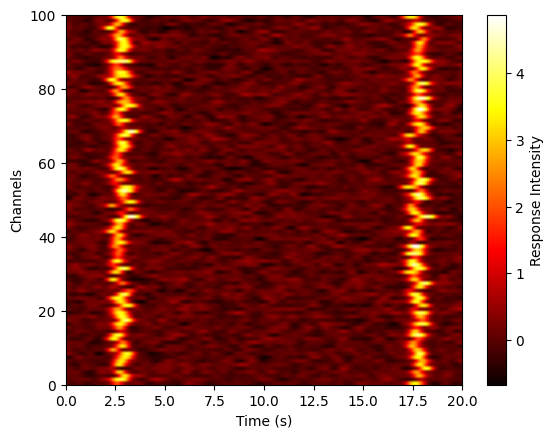

In [5]:
# Plot the time_res
plt.imshow(time_res[0].T, aspect='auto', cmap='hot', 
           extent=[0, time_res.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [6]:
labels = time_res.copy()

inputs = time_res.copy()
# Mask the inputs
from rtgym.utils.masking import Masking
mask = Masking(
                m_max=0.3,    # Maximum masking ratio
                m_min=0.1,    # Minimum masking ratio
                sigma_t=2.0,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=10,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )
inputs = mask.mask(inputs).numpy()
mask_start_idx = int(inputs.shape[1]*(sensory_profile['time']['event_onset'][0]+\
                                      sensory_profile['time']['event_width'][0]+\
                                      sensory_profile['time']['event_onset_sigma'][0]))
inputs[:, mask_start_idx:, :] = 0

Text(0, 0.5, 'Channels')

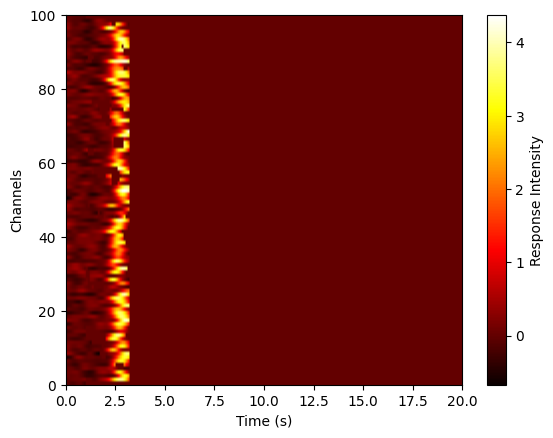

In [7]:
# Plot the masked inputs
plt.imshow(inputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, inputs.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [8]:
# Split the data to training and test set along axis=1
from torch.utils.data import DataLoader, TensorDataset
import torch
import nn4n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


indices = np.arange(inputs.shape[0])
train_inputs, test_inputs, train_labels, test_labels, train_indices, \
test_indices = train_test_split(inputs, labels, indices, test_size=0.05, random_state=42)

if isinstance(train_inputs, np.ndarray):
    train_inputs  = torch.from_numpy(train_inputs).float().to(device)
    train_labels  = torch.from_numpy(train_labels).float().to(device)
    test_inputs   = torch.from_numpy(test_inputs).float().to(device)
    test_labels   = torch.from_numpy(test_labels).float().to(device)

print('train_inputs:',  train_inputs.shape)
print('train_labels:',  train_labels.shape)
print('test_inputs:',   test_inputs.shape)
print('test_labels:',   test_labels.shape)
print('train_indices:', train_indices.shape)
print('test_indices:',  test_indices.shape)

train_dataset = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Using device: cuda
train_inputs: torch.Size([121, 200, 100])
train_labels: torch.Size([121, 200, 100])
test_inputs: torch.Size([7, 200, 100])
test_labels: torch.Size([7, 200, 100])
train_indices: (121,)
test_indices: (7,)


In [9]:
num_neuron = 512

# custom_alpha = 1 - np.exp(-np.linspace(0.1, 5, num_neuron))

model_cfg = {
            "input_dim":    train_inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   train_inputs.shape[2],
            "alpha":        0.3,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)


def custom_loss(recon, target, firing_rates, lambda_mse, lambda_r):
    """
    Args:
        recon: [batch, time, dim] — reconstructed experience vectors (ŷ)
        target: [batch, time, dim] — ground truth experience vectors (y)
        firing_rates: [batch, time, N] — firing rates of all hidden neurons
    """

    # Shape values
    B, T, D = target.shape
    N = firing_rates[0].shape[2]

    # 1. Reconstruction MSE Loss
    mse = torch.sum((recon - target) ** 2) / (B * T * D)
    # mse = torch.nn.MSELoss()
    # mse = mse(recon, target)

    # 2. Firing rate regularization term
    reg = torch.sum(torch.sum(firing_rates[0], axis=(0,1))**2 / (B * T)) / N

    total_loss = lambda_mse * mse + lambda_r * reg
    # print(lambda_mse * mse, lambda_r * reg)
    return total_loss, lambda_mse * mse, lambda_r * reg


optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [ ]:
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(2000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        # loss = criterion(batch_outputs, batch_labels)
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001
                           ) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 500 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)
    # if loss1 < 0.02:
    #     print("Early stopping due to low MSE loss.")
    #     break
    if  losses[-1] < 0.05 and abs(losses[-1] - losses[-50]) < 1e-4: # len(losses) > 50  :
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

  0%|          | 3/2000 [00:00<03:56,  8.44it/s]

Epoch 0 Loss 0.5339633226394653
tensor(0.5236, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0104, device='cuda:0', grad_fn=<MulBackward0>)


  5%|▌         | 109/2000 [00:08<02:23, 13.17it/s]

In [ ]:
plt.figure()
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  
plt.tight_layout()

In [ ]:
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

In [ ]:
# Plot the masked inputs
plt.imshow(test_outputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, test_outputs.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [ ]:
def plt_hs(hs, min_fr=0.1, masks=None, fig=None, ax=None):

    time_points = hs.shape[0]

    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    num_neurons = norm_hs.shape[1]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_points/10, 0, num_neurons]
              )
    # ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))

    if masks is not None:
        for m in masks:
            ax.axvline(x=m[0], color='white', linestyle='--', linewidth=1)
            ax.axvline(x=m[1], color='white', linestyle='-', linewidth=1)
            # Plot a semi-transparent rectangle to cover the masked region
            ax.add_patch(plt.Rectangle((m[0], 0), m[1]-m[0], norm_hs.shape[1], 
                                       color='white', alpha=0.3))
    
    # # Plot the colorbar
    # cbar = fig.colorbar(ax.images[0], ax=ax)
    # cbar.set_label('Normalized firing rate')
    return norm_hs, fig, ax

In [ ]:
# Averge accross the batch
avg_hs = np.mean(hidden_states, axis=0)
print(avg_hs.shape)

fig, ax = plt.subplots(figsize=(5, 4))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax)
print(norm_hs.shape)
ax.set_xlabel('Time (s)')

In [ ]:
# Sort the norm_hs with maximum firing time
max_time_pts = np.argmax(norm_hs, axis=0)

threshold = 0.5
delta = 0.1

# For regions left to the max time pts, find the index where the firing rate is closest to 0.7 and between 0.65 and 0.75
firing_starts = np.zeros(norm_hs.shape[1])
for i in range(norm_hs.shape[1]):
    left_half = norm_hs[:max_time_pts[i], i]
    if np.any((left_half > threshold-delta) & (left_half < threshold+delta)):
        firing_starts[i] = np.where((left_half > threshold-delta) & (left_half < threshold+delta))[0][-1]
        
    else:
        firing_starts[i] = np.nan

# For regions right to the max time pts, find the index where the firing rate is closest to 0.7 and between 0.65 and 0.75
firing_ends = np.zeros(norm_hs.shape[1])
for i in range(norm_hs.shape[1]):
    right_half = norm_hs[max_time_pts[i]:, i]
    if np.any((right_half > threshold-delta) & (right_half < threshold+delta)):
        firing_ends[i] = max_time_pts[i] + np.where((right_half > threshold-delta) & (right_half < threshold+delta))[0][0]
    else:
        firing_ends[i] = np.nan

firing_widths = firing_ends - firing_starts

# Change the unit to time (s)
max_time_pts = max_time_pts / 10
firing_starts = firing_starts / 10
firing_ends = firing_ends / 10
firing_widths = firing_widths / 10

In [ ]:
def plt_corr(time_pts, widths, fig, ax):
    
    # calculate the fitted gradient
    from scipy.optimize import curve_fit
    def fit_func(x, a, b):
        return a * x + b
    popt, pcov = curve_fit(fit_func, time_pts, widths)  
    print(f'Fitted gradient: {popt[0]:.4f}')

    # use seaborn to plot the correlation of red dots with shaded area
    import seaborn as sns
    rval = np.corrcoef(time_pts, widths)[0,1]
    print(f'Correlation coefficient: {rval}')
    sns.regplot(x=time_pts, y=widths,
                scatter=False, 
                color='black',
                line_kws={"linewidth":1, "linestyle":"-"},
                ci=95,
                label=f'r = {rval:.2f}; gradient = {popt[0]:.4f}')

    return fig, ax

In [ ]:
# Plot the firing widths vs the maximum firing times
fig, ax = plt.subplots(figsize=(5,4))

time_start = 3.5
time_critical = 12 #inputs.shape[1]*(sensory_profile['time']['event_onset'][1]) / 10

plt.scatter(max_time_pts[(time_start <= max_time_pts) & (max_time_pts < time_critical)], 
            firing_widths[(time_start <= max_time_pts) & (max_time_pts < time_critical)], c='salmon', s=10)
plt.scatter(max_time_pts[(time_start <= max_time_pts) & (max_time_pts > time_critical)], 
            firing_widths[(time_start <= max_time_pts) & (max_time_pts > time_critical)], c='skyblue', s=10)

# Plot where not nan firing widths
not_nan_mask = ~np.isnan(firing_widths)
max_time_pts = max_time_pts[not_nan_mask]
firing_widths = firing_widths[not_nan_mask]
firing_starts = firing_starts[not_nan_mask]
firing_ends = firing_ends[not_nan_mask]
norm_hs = norm_hs[:, not_nan_mask]

plt_corr(max_time_pts[(time_start <= max_time_pts) & (max_time_pts < time_critical)], 
         firing_widths[(time_start <= max_time_pts) & (max_time_pts < time_critical)], fig=fig, ax=ax)
# plt.ylim(0, 6)
plt.xlabel('Maximum firing time (s)')
plt.ylabel("Firing width (s)")
plt.legend()